In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

In [17]:
OUT_PUT = "./data/train.parquet"

df = pd.read_parquet("data/flight.parquet", engine="pyarrow")
df

,flight,payload,route,altitude,date,time_day,duration_s,total_distance_m,wind_speed_mean,wind_speed_std,...,wind_y_mean,speed_mean,speed_max,velocity_mag_mean,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std,battery_voltage_mean,battery_voltage_min,battery_needed
0,1,0.0,R5,25,2019-04-07,10:13,200.70,76.894875,3.898058,1.952675,...,-1.246141,4.0,4.0,2.676774,6.261616,9.842870,0.466372,22.070134,21.228519,1000.743935
1,2,0.0,R5,50,2019-04-07,10:23,271.20,125.616211,3.522941,2.159456,...,-1.886357,4.0,4.0,2.387432,7.676739,9.881874,0.628406,21.527547,20.125463,1205.255874
2,3,0.0,R5,25,2019-04-07,10:33,180.10,71.228093,4.581182,3.335733,...,-1.778235,6.0,6.0,3.110644,7.213987,9.902090,0.545290,22.330305,19.943916,789.073853
3,4,0.0,R5,25,2019-04-07,10:48,171.00,78.000098,4.596319,3.438072,...,-1.389653,8.0,8.0,3.165734,9.425537,9.900368,0.559073,21.950616,20.365856,687.813976
4,5,0.0,R2,25,2019-04-07,11:05,217.00,71.103672,3.333910,2.247522,...,-1.257258,4.0,4.0,2.126439,4.900079,9.817243,0.341981,21.519937,18.923494,920.070980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
204,275,500.0,R1,25,2019-10-24,9:05,149.40,59.757821,4.139878,3.885389,...,-0.676045,8.0,8.0,3.336389,8.788151,9.850903,0.420902,22.056616,20.332052,760.480643
205,276,500.0,R1,25,2019-10-24,9:32,147.90,61.401245,4.392581,4.332293,...,-0.635730,10.0,10.0,3.402998,10.553163,9.862172,0.471081,21.492353,19.788662,738.620356
206,277,500.0,R1,25,2019-10-24,9:45,134.81,64.842379,5.524651,4.029744,...,-1.457703,10.0,10.0,3.680124,10.579715,9.847796,0.529103,21.908016,19.352947,741.451254
207,278,500.0,R7,25-50-100-25,2019-10-24,10:00,186.39,197.253052,4.686967,3.826570,...,-1.806563,10.0,10.0,2.907930,10.376503,9.829065,0.456918,22.394109,20.407175,887.198699


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 209 entries, 0 to 208
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   flight                 209 non-null    int64   
 1   payload                209 non-null    float64 
 2   route                  209 non-null    category
 3   altitude               209 non-null    string  
 4   date                   209 non-null    str     
 5   time_day               209 non-null    str     
 6   duration_s             209 non-null    float64 
 7   total_distance_m       209 non-null    float64 
 8   wind_speed_mean        209 non-null    float64 
 9   wind_speed_std         209 non-null    float64 
 10  wind_x_mean            209 non-null    float64 
 11  wind_y_mean            209 non-null    float64 
 12  speed_mean             209 non-null    float64 
 13  speed_max              209 non-null    float64 
 14  velocity_mag_mean      209 non-null    float64 
 15  

In [15]:
del df
gc.collect()
%whos

Variable         Type         Data/Info
---------------------------------------
OUT_PUT          str          ./data/train.parquet
X                DataFrame    Shape: (209, 12)
corr             DataFrame    Shape: (17, 17)
gc               module       <module 'gc' (built-in)>
mask             ndarray      17x17: 289 elems, type `bool`, 289 bytes
np               module       <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
num_cols         Index        Index(['flight', 'payload<...>ed'],\n      dtype='str')
pd               module       <module 'pandas' from '/h<...>ages/pandas/__init__.py'>
plt              module       <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
selection_cols   list         n=12
sns              module       <module 'seaborn' from '/<...>ges/seaborn/__init__.py'>
target_corr      Series       Shape: (16,)


In [19]:
df.columns

Index(['flight', 'payload', 'route', 'altitude', 'date', 'time_day',
       'duration_s', 'total_distance_m', 'wind_speed_mean', 'wind_speed_std',
       'wind_x_mean', 'wind_y_mean', 'speed_mean', 'speed_max',
       'velocity_mag_mean', 'velocity_mag_max', 'acceleration_mag_mean',
       'acceleration_mag_std', 'battery_voltage_mean', 'battery_voltage_min',
       'battery_needed'],
      dtype='str')

In [20]:
selection_cols = [
    "payload",
    "total_distance_m",
    "wind_speed_mean",
    "wind_speed_std",
    "wind_x_mean",
    "wind_y_mean",
    'velocity_mag_mean',
    'velocity_mag_max',
    'acceleration_mag_mean',
    'acceleration_mag_std',
    "battery_needed",
]

In [21]:
X = df[selection_cols]
X

,payload,total_distance_m,wind_speed_mean,wind_speed_std,wind_x_mean,wind_y_mean,velocity_mag_mean,velocity_mag_max,acceleration_mag_mean,acceleration_mag_std,battery_needed
0,0.0,76.894875,3.898058,1.952675,0.973186,-1.246141,2.676774,6.261616,9.842870,0.466372,1000.743935
1,0.0,125.616211,3.522941,2.159456,0.088843,-1.886357,2.387432,7.676739,9.881874,0.628406,1205.255874
2,0.0,71.228093,4.581182,3.335733,-0.696895,-1.778235,3.110644,7.213987,9.902090,0.545290,789.073853
3,0.0,78.000098,4.596319,3.438072,-0.351732,-1.389653,3.165734,9.425537,9.900368,0.559073,687.813976
4,0.0,71.103672,3.333910,2.247522,0.062744,-1.257258,2.126439,4.900079,9.817243,0.341981,920.070980
...,...,...,...,...,...,...,...,...,...,...,...
204,500.0,59.757821,4.139878,3.885389,0.336196,-0.676045,3.336389,8.788151,9.850903,0.420902,760.480643
205,500.0,61.401245,4.392581,4.332293,0.252633,-0.635730,3.402998,10.553163,9.862172,0.471081,738.620356
206,500.0,64.842379,5.524651,4.029744,-0.785881,-1.457703,3.680124,10.579715,9.847796,0.529103,741.451254
207,500.0,197.253052,4.686967,3.826570,-0.546397,-1.806563,2.907930,10.376503,9.829065,0.456918,887.198699


In [22]:
X.to_parquet(OUT_PUT, index= False, compression= 'zstd')

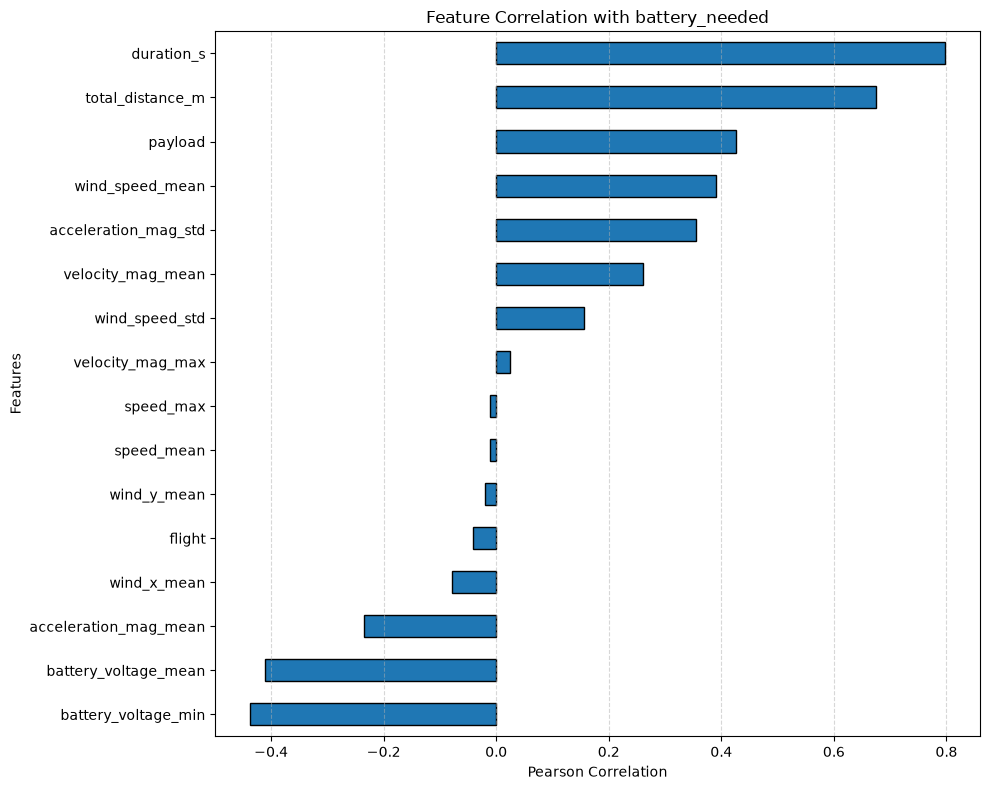

In [7]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Correlation with target
target_corr = (
    corr["battery_needed"]
    .drop("battery_needed")      # Remove self-correlation
    .sort_values()
)

plt.figure(figsize=(10, 8))

target_corr.plot(
    kind="barh",                  # Horizontal bar chart
    edgecolor="black"
)

plt.title("Feature Correlation with battery_needed")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

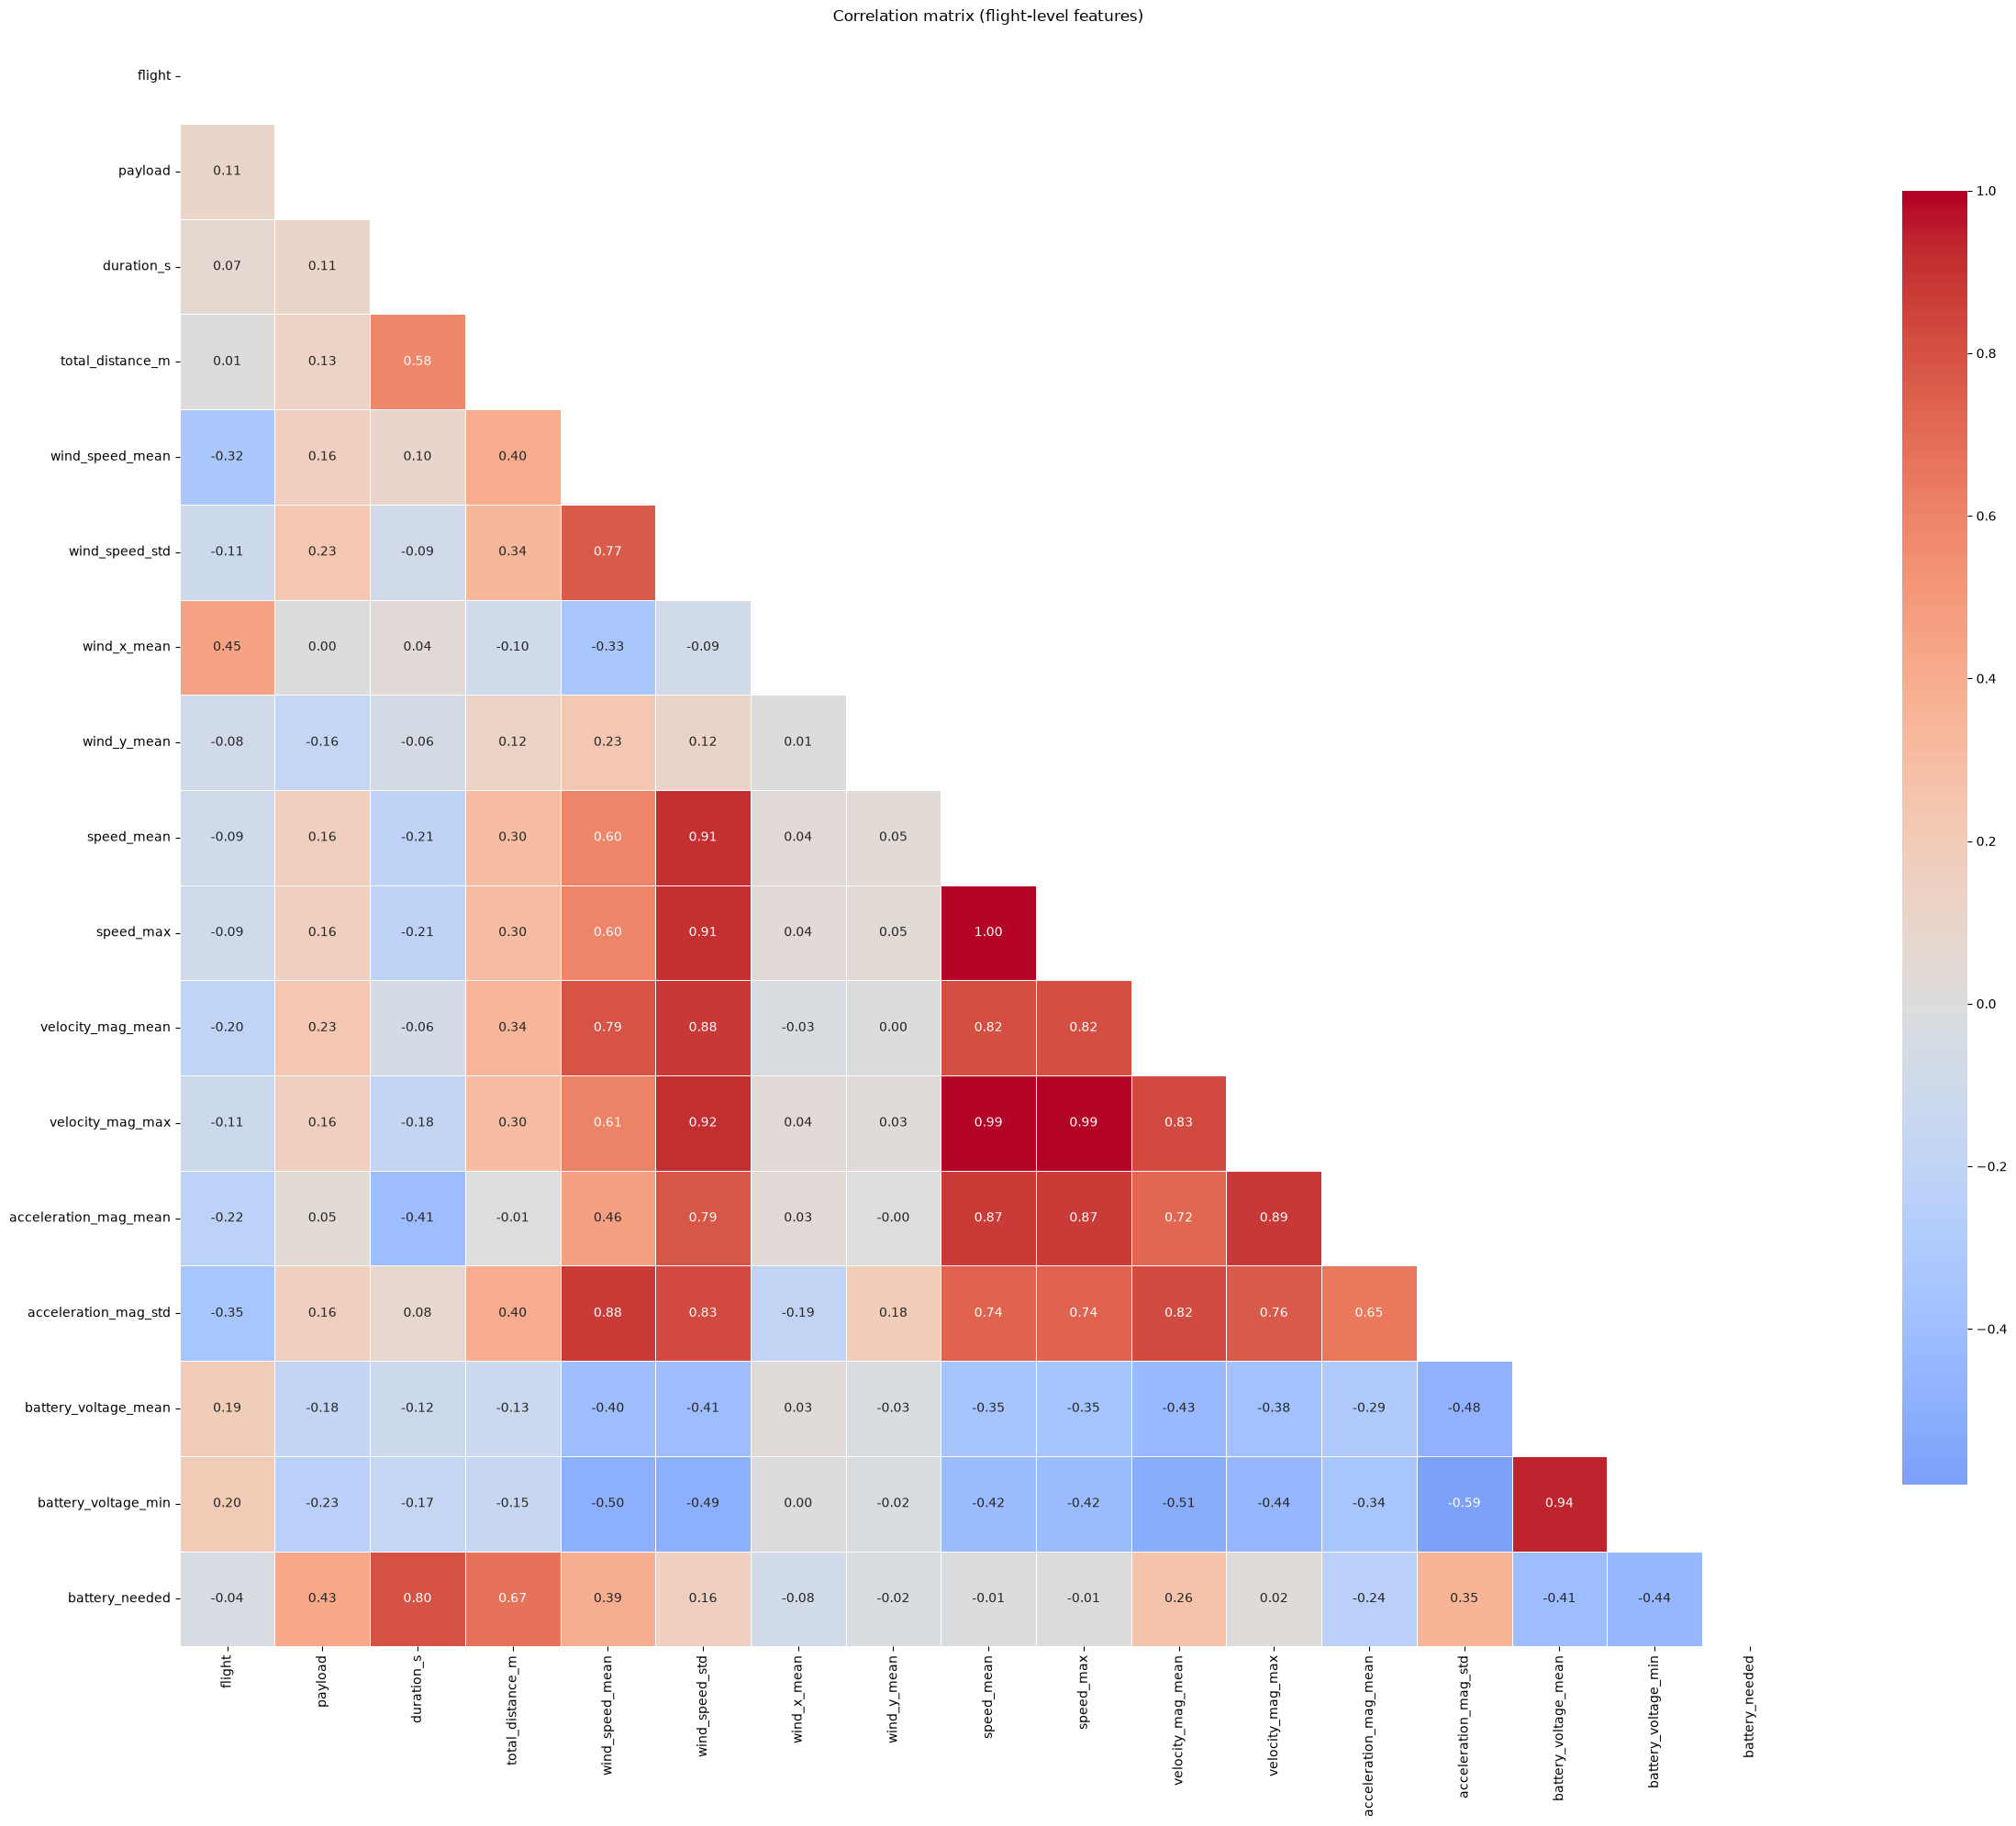

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(25, 20))
sns.heatmap(corr,
        mask=mask,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
        annot= True,
        fmt='.2f',
        cbar_kws={"shrink": 0.8}
            )
plt.title("Correlation matrix (flight-level features)")
plt.tight_layout()
plt.show()